In [1]:
# Import required libaries

import os
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# BASE_DIR = parent directory of the current working directory (project root)

BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
BASE_DIR

'd:\\CS406_FINAL_PROJECT'

In [3]:
# DATA_DIR = data directory

DATA_DIR = os.path.join(BASE_DIR, 'data')
DATA_DIR

'd:\\CS406_FINAL_PROJECT\\data'

In [4]:
# INPUT_DIRS = input directories containing .mat MRI files

INPUT_DIRS = [
    os.path.join(DATA_DIR, 'raw', 'brainTumorDataPublic_1-766'),
    os.path.join(DATA_DIR, 'raw', 'brainTumorDataPublic_767-1532'),
    os.path.join(DATA_DIR, 'raw', 'brainTumorDataPublic_1533-2298'),
    os.path.join(DATA_DIR, 'raw', 'brainTumorDataPublic_2299-3064'),
]
INPUT_DIRS

['d:\\CS406_FINAL_PROJECT\\data\\raw\\brainTumorDataPublic_1-766',
 'd:\\CS406_FINAL_PROJECT\\data\\raw\\brainTumorDataPublic_767-1532',
 'd:\\CS406_FINAL_PROJECT\\data\\raw\\brainTumorDataPublic_1533-2298',
 'd:\\CS406_FINAL_PROJECT\\data\\raw\\brainTumorDataPublic_2299-3064']

In [5]:
# SAVE_DIR = directory to save processed PNG images

SAVE_DIR = os.path.join(DATA_DIR, 'processed')
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
SAVE_DIR

'd:\\CS406_FINAL_PROJECT\\data\\processed'

In [6]:
# Mapping numeric labels to tumor names

LABELS_MAP = {
    1: 'Meningioma Tumor',
    2: 'Glioma Tumor',
    3: 'Pituitary Tumor',
}
LABELS_MAP

{1: 'Meningioma Tumor', 2: 'Glioma Tumor', 3: 'Pituitary Tumor'}

In [7]:
# Load one sample .mat file to inspect its structure

sample_file = None

for folder in INPUT_DIRS:
    files = [f for f in os.listdir(folder) if f.endswith('.mat')]
    print(files)
    if files:
        sample_file = os.path.join(folder, files[0])
        print(sample_file)
        break

['1.mat', '10.mat', '100.mat', '101.mat', '102.mat', '103.mat', '104.mat', '105.mat', '106.mat', '107.mat', '108.mat', '109.mat', '11.mat', '110.mat', '111.mat', '112.mat', '113.mat', '114.mat', '115.mat', '116.mat', '117.mat', '118.mat', '119.mat', '12.mat', '120.mat', '121.mat', '122.mat', '123.mat', '124.mat', '125.mat', '126.mat', '127.mat', '128.mat', '129.mat', '13.mat', '130.mat', '131.mat', '132.mat', '133.mat', '134.mat', '135.mat', '136.mat', '137.mat', '138.mat', '139.mat', '14.mat', '140.mat', '141.mat', '142.mat', '143.mat', '144.mat', '145.mat', '146.mat', '147.mat', '148.mat', '149.mat', '15.mat', '150.mat', '151.mat', '152.mat', '153.mat', '154.mat', '155.mat', '156.mat', '157.mat', '158.mat', '159.mat', '16.mat', '160.mat', '161.mat', '162.mat', '163.mat', '164.mat', '165.mat', '166.mat', '167.mat', '168.mat', '169.mat', '17.mat', '170.mat', '171.mat', '172.mat', '173.mat', '174.mat', '175.mat', '176.mat', '177.mat', '178.mat', '179.mat', '18.mat', '180.mat', '181.mat'

In [8]:
# Open the .mat file using h5py

f = h5py.File(sample_file, 'r')
print(f)
print(list(f.keys()))

<HDF5 file "1.mat" (mode r)>
['cjdata']


In [9]:
# Access the cjdata group

cjdata = f['cjdata']
print(cjdata)
print(cjdata.keys())

<HDF5 group "/cjdata" (5 members)>
<KeysViewHDF5 ['PID', 'image', 'label', 'tumorBorder', 'tumorMask']>


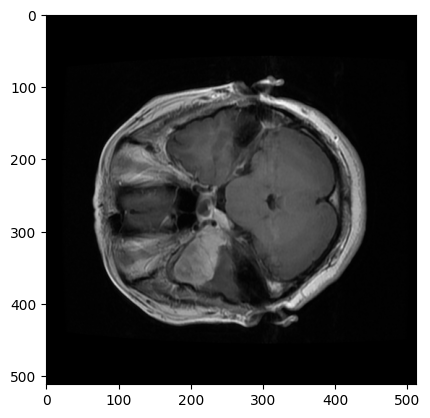

In [10]:
# Extract and display the raw MRI image

raw_image = np.array(cjdata['image'])
plt.imshow(raw_image, cmap='gray')

In [11]:
# Extract tumor label

label = LABELS_MAP[int(cjdata['label'][0][0])]
f'Label: {label}'

'Label: Meningioma Tumor'

In [12]:
# Inspect original pixel value range

f'Pixel value (min - max): {raw_image.min()} - {raw_image.max()}'

'Pixel value (min - max): 0 - 3366'

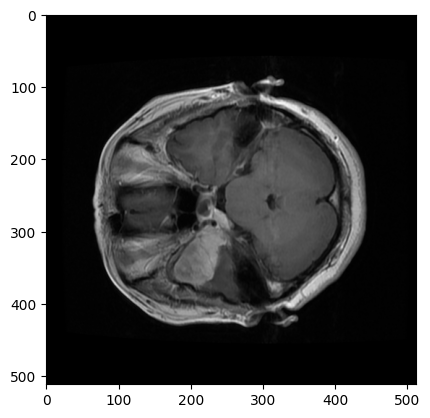

In [13]:
# Scale pixel values to range [0, 1], then convert to [0, 255] and uint8 type

normalized_image = (raw_image - raw_image.min()) / (raw_image.max() - raw_image.min()) * 255.0
normalized_image = normalized_image.astype(np.uint8)
plt.imshow(normalized_image, cmap='gray')

In [14]:
# Inspect normalized pixel value range

f'Pixel value (min - max): {normalized_image.min()} - {normalized_image.max()}'

'Pixel value (min - max): 0 - 255'

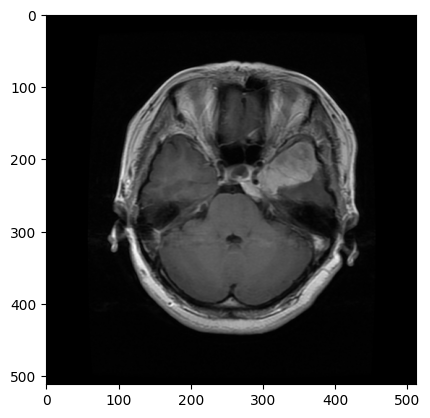

In [15]:
# MATLAB uses column-major (columns, rows) while Python use row-major (rows, columns) so transpose ensures correct orientation

final_image = normalized_image.T
plt.imshow(final_image, cmap='gray')

In [16]:
# Process entire dataset and save PNG images

for folder in INPUT_DIRS:
    files = [f for f in os.listdir(folder) if f.endswith('.mat')]
    
    for file in tqdm(files):
        mat_path = os.path.join(folder, file)

        with h5py.File(mat_path, 'r') as f:
            cjdata = f['cjdata']

            # Process image
            raw_image = np.array(cjdata['image'])
            normalized_image = (raw_image - raw_image.min()) / (raw_image.max() - raw_image.min()) * 255.0
            final_image = normalized_image.astype(np.uint8).T
            
            # Output PNG file path
            save_path = os.path.join(SAVE_DIR, file.replace('.mat', '.png'))
            
            # Save image as PNG
            Image.fromarray(final_image).save(save_path)

100%|██████████| 766/766 [00:34<00:00, 21.96it/s]


In [17]:
# Verify number of processed images

png_files = [f for f in os.listdir(SAVE_DIR) if f.endswith('.png')]
f'{len(png_files)} processed images'

'3064 processed images'